# EigenMap: Cell-Type Attribution Maps

Start simple: one sequence that is highly active in both K562 and HepG2.
DeepLIFT/SHAP attributions through each cell-type model, side by side.

In [1]:
import os, sys, importlib, pathlib
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

# Auto-clear stale bytecode so reload() always picks up edits
for pyc in pathlib.Path('..', '__pycache__').glob('eigen_steering.cpython-*.pyc'):
    pyc.unlink(missing_ok=True)

import numpy as np
import pandas as pd
import eigen_steering; importlib.reload(eigen_steering)
from eigen_steering import EigenMap, PROMOTER_SEQ, RAND_BARCODE

# Load joint library
joint_df = pd.read_csv('/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/Cell_line_MoCon/Cross-line_analysis/pred_first/joint_data/joint_library_combined.csv')
joint_df = joint_df.dropna(subset=['sequence', 'K562_log2FC', 'HepG2_log2FC']).reset_index(drop=True)

# Build full 281bp constructs for prediction
constructs = [s + PROMOTER_SEQ + RAND_BARCODE for s in joint_df['sequence']]

# Predict all sequences with both models, add error columns
em_screen = EigenMap(cell_types=['K562', 'HepG2'])
preds = em_screen.predict(constructs)
for ct in ['K562', 'HepG2']:
    joint_df[f'{ct}_pred'] = preds[ct]
    joint_df[f'{ct}_err'] = (joint_df[f'{ct}_pred'] - joint_df[f'{ct}_log2FC']).abs()

# Filter: both models must predict within max_err of actual
MAX_ERR = 0.5
well_pred = joint_df[(joint_df['K562_err'] < MAX_ERR) & (joint_df['HepG2_err'] < MAX_ERR)].copy()
well_pred['min_expr'] = well_pred[['K562_log2FC', 'HepG2_log2FC']].min(axis=1)
print(f"Well-predicted sequences (|err| < {MAX_ERR}): {len(well_pred)} / {len(joint_df)}")

# Select representative sequences from well-predicted pool
high_high = well_pred.nlargest(1, 'min_expr')
k562_high = well_pred.nlargest(1, 'K562_log2FC')
hepg2_high = well_pred.nlargest(1, 'HepG2_log2FC')
selected = pd.concat([high_high, k562_high, hepg2_high]).drop_duplicates(subset='sequence').reset_index(drop=True)
for i, r in selected.iterrows():
    print(f"  [{i}] K562={r['K562_log2FC']:+.2f} (pred {r['K562_pred']:+.2f}), "
          f"HepG2={r['HepG2_log2FC']:+.2f} (pred {r['HepG2_pred']:+.2f})")

# Load all selected sequences into one EigenMap
em = EigenMap(cell_types=['K562', 'HepG2'])
em.load_sequences(selected['sequence'].tolist())
em.set_actual({ct: selected[f'{ct}_log2FC'].values for ct in ['K562', 'HepG2']})

AlphaGenome patches applied (all functional activations -> nn.Module).
EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_twostep_v4_do03', 'HepG2': 'HepG2_twostep_v4_do03'}
  Loading K562: /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/training/results/K562_twostep_v4_do03/checkpoints/best_stage2.pt
  Loading HepG2: /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/training/results/HepG2_twostep_v4_do03/checkpoints/best_stage2.pt
Well-predicted sequences (|err| < 0.5): 36816 / 56975
  [0] K562=+2.30 (pred +1.80), HepG2=+2.14 (pred +1.99)
  [1] K562=+2.70 (pred +2.51), HepG2=-0.61 (pred -0.66)
  [2] K562=-0.39 (pred -0.22), HepG2=+4.98 (pred +4.54)
EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_twostep_v4_do03', 'HepG2': 'HepG2_twostep_v4_do03'}
Loaded 3 sequences, X shape: torch.Size([3, 4, 281])


In [2]:
em.compute_attributions(method='deeplift', n_shuffles=20)

DeepLIFT/SHAP: K562...
  Loading K562: /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/training/results/K562_twostep_v4_do03/checkpoints/best_stage2.pt


  0%|          | 0/60 [00:00<?, ?it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.7923, 1.0615, 0.3600, 0.5945, 0.9107, 0.8042, 0.8648, 1.0831, 0.6110,
        0.7790, 0.9917, 0.9057, 0.7116, 1.0230, 1.0854, 0.5434, 0.8079, 1.3716,
        0.7276, 1.2064], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
 33%|███▎      | 20/60 [00:00<00:00, 57.35it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([1.4715, 1.7571, 1.3215, 1.3002, 1.4496, 1.5702, 1.5287, 1.3096, 1.5208,
        1.3114, 1.2772, 1.4489, 1.4480, 1.3886, 1.2992, 1.4047, 1.1776, 1.4289,
        1.5072, 1.5595], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
 67%|██████▋   | 40/6

DeepLIFT/SHAP: HepG2...
  Loading HepG2: /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/training/results/HepG2_twostep_v4_do03/checkpoints/best_stage2.pt


  0%|          | 0/60 [00:00<?, ?it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([1.0086, 1.3148, 0.2416, 0.7858, 1.0126, 1.0036, 1.1580, 1.1081, 0.6276,
        1.0590, 1.1469, 1.0821, 0.9492, 1.1538, 1.3238, 0.5638, 0.8762, 1.3793,
        0.9508, 1.2011], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
 33%|███▎      | 20/60 [00:00<00:00, 76.87it/s]/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/tangermeme/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.2898, 0.4768, 0.0612, 0.2651, 0.1358, 0.4362, 0.2500, 0.0382, 0.3027,
        0.0283, 0.3306, 0.3120, 0.1362, 0.1114, 0.3379, 0.2167, 0.2660, 0.3363,
        0.0511, 0.3914], device='cuda:0', grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
 67%|██████▋   | 40/6

(<Figure size 1800x600 with 2 Axes>,
 array([<Axes: title={'center': 'K562 | K562_twostep_v4_do03 | pred=2.505 | actual=2.701'}, ylabel='Attribution'>,
        <Axes: title={'center': 'HepG2 | HepG2_twostep_v4_do03 | pred=-0.659 | actual=-0.608'}, xlabel='Position (230bp enhancer | 36bp promoter | 15bp barcode)', ylabel='Attribution'>],
       dtype=object))

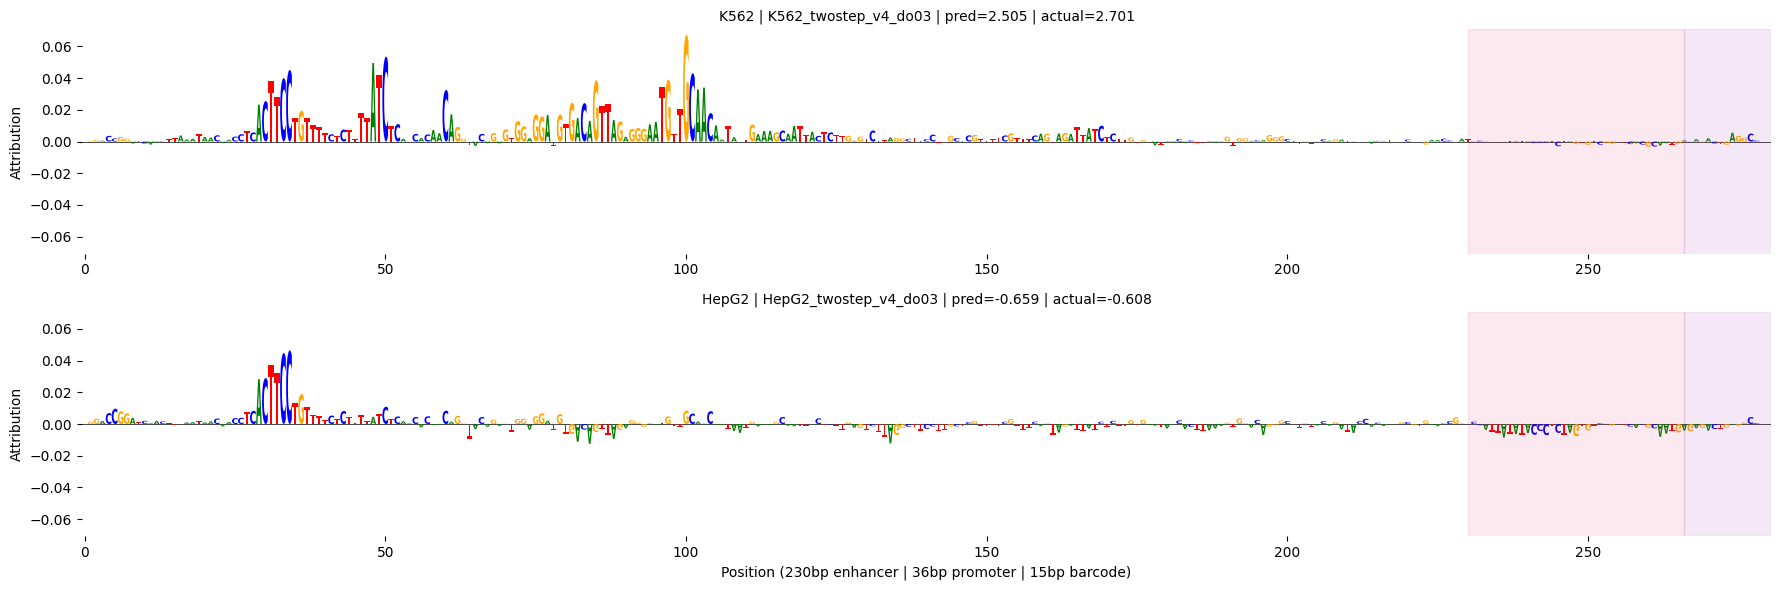

In [3]:
em.plot_attr_logos(seq_idx=1)

  K562: 8 motif hits (p<0.05)
  HepG2: 8 motif hits (p<0.05)
  K562: 4 hits
    [ 72- 97] ELF4(p=9.1e-05), ZNF335(p=2.7e-04), Prdm15(p=5.3e-04)  (enhancer)
    [116-141] Ahr::Arnt(p=3.6e-04), TFEC(p=6.1e-04), PAX9(p=1.8e-03)  (enhancer)
    [164-189] ATF4(p=9.1e-05), CEBPG(p=2.6e-04), Dux(p=1.1e-03)  (enhancer)
    [208-233] Ahr::Arnt(p=6.4e-04), PAX5(p=4.9e-03), ZFP57(p=9.1e-03)  (promoter)
  HepG2: 4 hits
    [ 71- 96] ZNF335(p=1.6e-05), ELF4(p=9.0e-05), Prdm15(p=5.2e-04)  (enhancer)
    [116-141] Ahr::Arnt(p=3.6e-04), TFEC(p=6.1e-04), PAX9(p=1.8e-03)  (enhancer)
    [164-189] ATF4(p=9.1e-05), CEBPG(p=2.6e-04), Dux(p=1.1e-03)  (enhancer)
    [195-220] HES7(p=6.5e-04), ZNF610(p=1.2e-03), CGGBP1(p=1.2e-03)  (enhancer)


(<Figure size 1800x900 with 2 Axes>,
 array([<Axes: title={'center': 'K562 | K562_twostep_v4_do03 | pred=1.803 | actual=2.297'}, ylabel='Attribution'>,
        <Axes: title={'center': 'HepG2 | HepG2_twostep_v4_do03 | pred=1.990 | actual=2.143'}, xlabel='Position (230bp enhancer | 36bp promoter | 15bp barcode)', ylabel='Attribution'>],
       dtype=object))

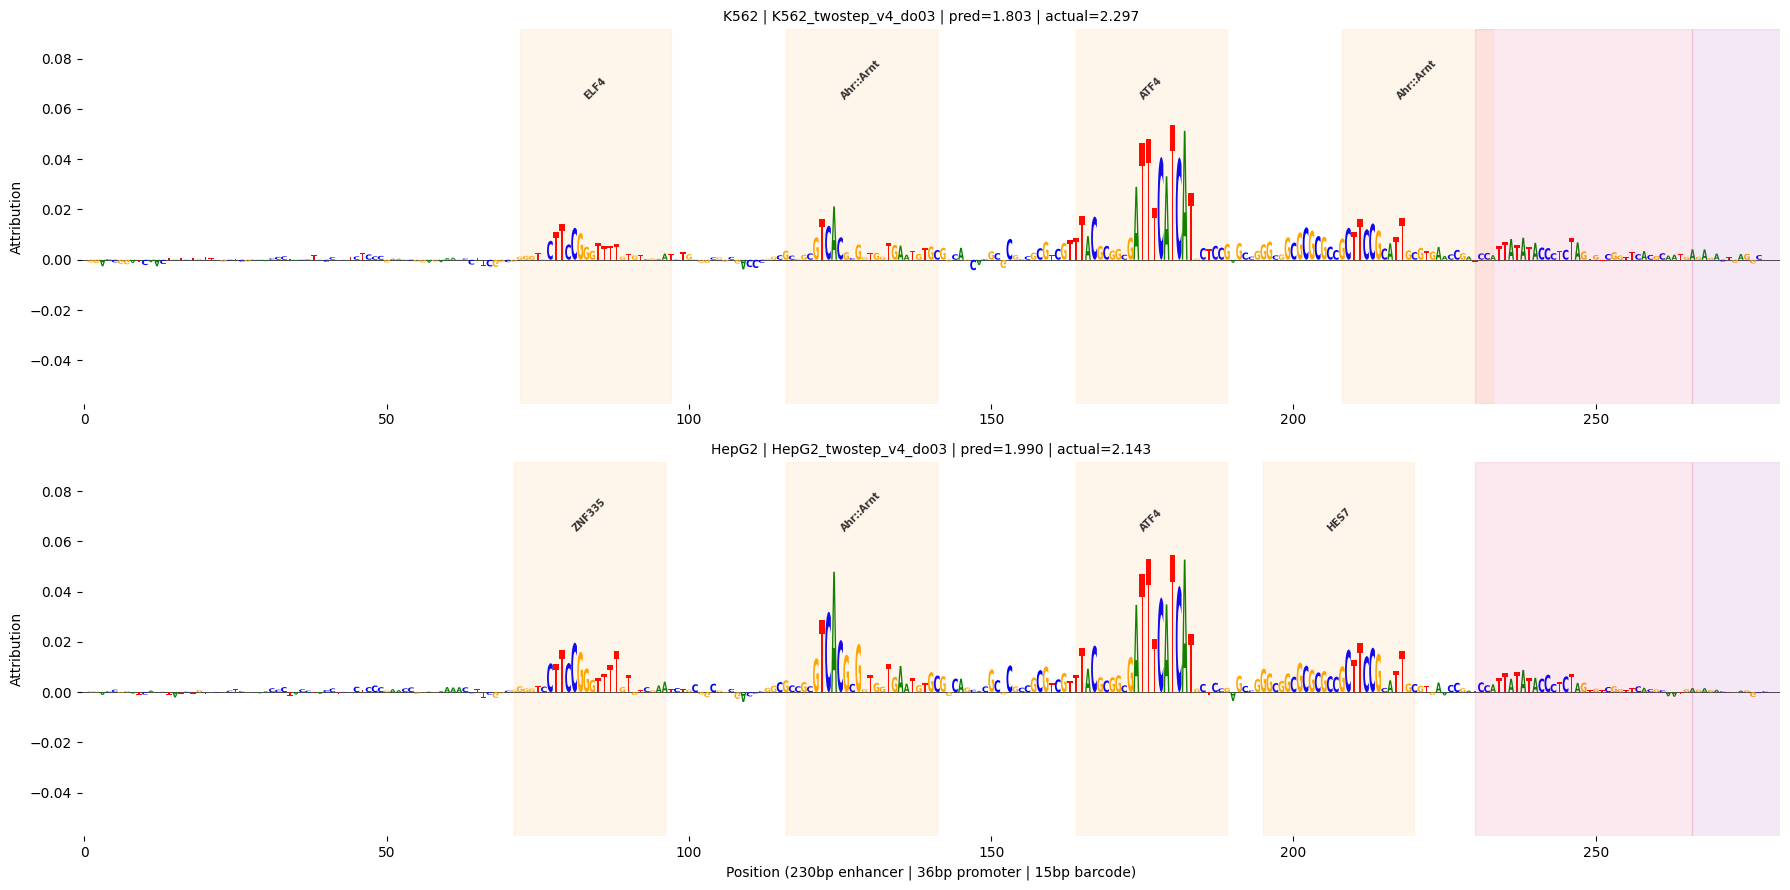

In [4]:
em.annotate_motifs(window_size=15, flank=5)
em.show_motifs(seq_idx=0)
em.plot_attr_logos_with_motifs(seq_idx=0)

  K562: 58721 genes, median TPM=0.00
  HepG2: 58721 genes, median TPM=0.00
  TF lookup: 57133 gene symbols across ['K562', 'HepG2']
  K562: 9 motif hits (p<0.05)
  HepG2: 8 motif hits (p<0.05)
  [ 20- 47] FOXO1::FLI1     components=[FOXO1+FLI1] paralogs=[FOXO3, FOXO4, FOXO3B]
  [ 49- 75] SCRT2           components=[SCRT2] paralogs=[none]
  [ 87-113] TEAD2           components=[TEAD2] paralogs=[TEAD4, TEAD1, TEAD3]
  [154-180] ZNF780B         components=[ZNF780B] paralogs=[ZNF595, ZNF207, ZNF638, ZNF124, ZNF146]


/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/eigen_steering.py:1585: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(<Figure size 2000x1030 with 2 Axes>,
 [<Axes: title={'center': 'K562 | K562_twostep_v4_do03 | pred=2.505 | actual=2.701'}>,
  <Axes: title={'center': 'HepG2 | HepG2_twostep_v4_do03 | pred=-0.659 | actual=-0.608'}, xlabel='Position (230bp enhancer | 36bp promoter | 15bp barcode)'>])

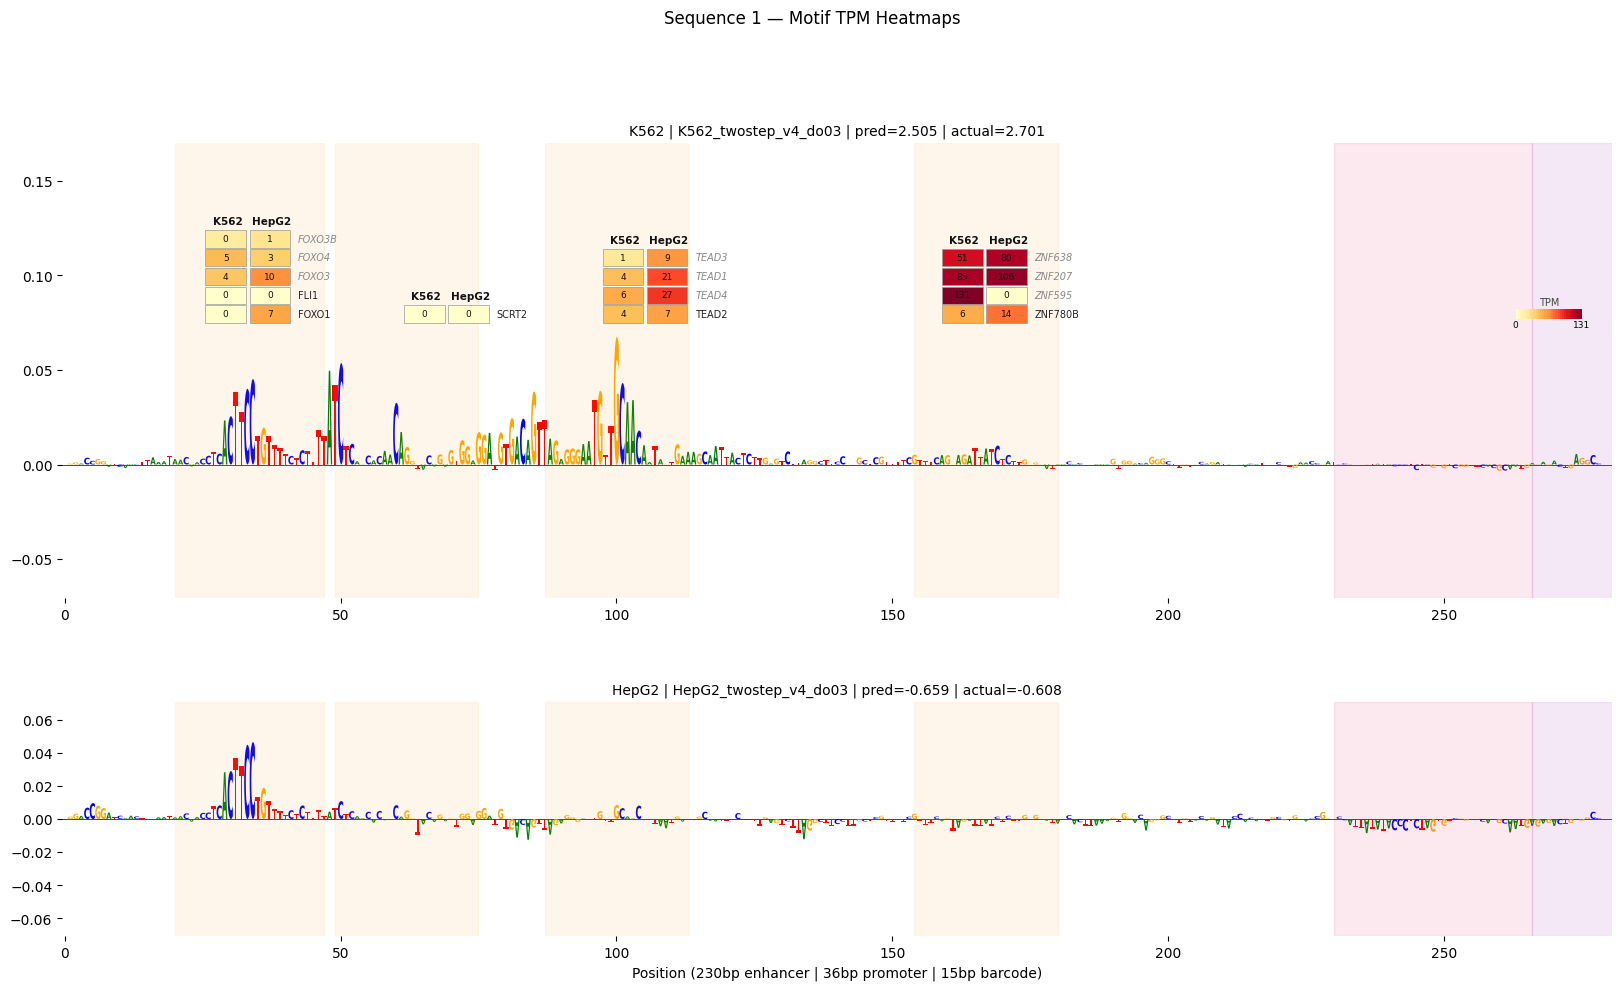

In [14]:
# Download ENCODE expression (HepG2, K562) and match motif hits to TF expression
seq_idx = 1
top_k = 1
max_paralogs = 3
em.load_expression()
em.annotate_motifs(window_size=10, flank=8, n_nearest=3)

# Show top expressed TOMTOM hit + paralogs
matches = em.expression_match(seq_idx=seq_idx, top_k=top_k, min_tpm=1.0)
for m in matches:
    comps = '+'.join(m['components'])
    paras = ', '.join(m['paralogs']) if m['paralogs'] else 'none'
    print(f"  [{m['start']:3d}-{m['end']:3d}] {m['tf']:15s} components=[{comps}] paralogs=[{paras}]")

# annotation_style='bars' (default) or 'heatmap'
em.plot_expression_match(seq_idx=seq_idx, top_k=top_k, max_paralogs=max_paralogs, annotation_style='heatmap')

  K562: 10547 proteins quantified, median log2=-0.06
  HepG2: 8904 proteins quantified, median log2=-0.13
  Protein lookup: 10649 genes across ['K562', 'HepG2']


/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/interp/eigen_steering.py:1585: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(<Figure size 2000x958 with 2 Axes>,
 [<Axes: title={'center': 'K562 | K562_twostep_v4_do03 | pred=2.505 | actual=2.701'}>,
  <Axes: title={'center': 'HepG2 | HepG2_twostep_v4_do03 | pred=-0.659 | actual=-0.608'}, xlabel='Position (230bp enhancer | 36bp promoter | 15bp barcode)'>])

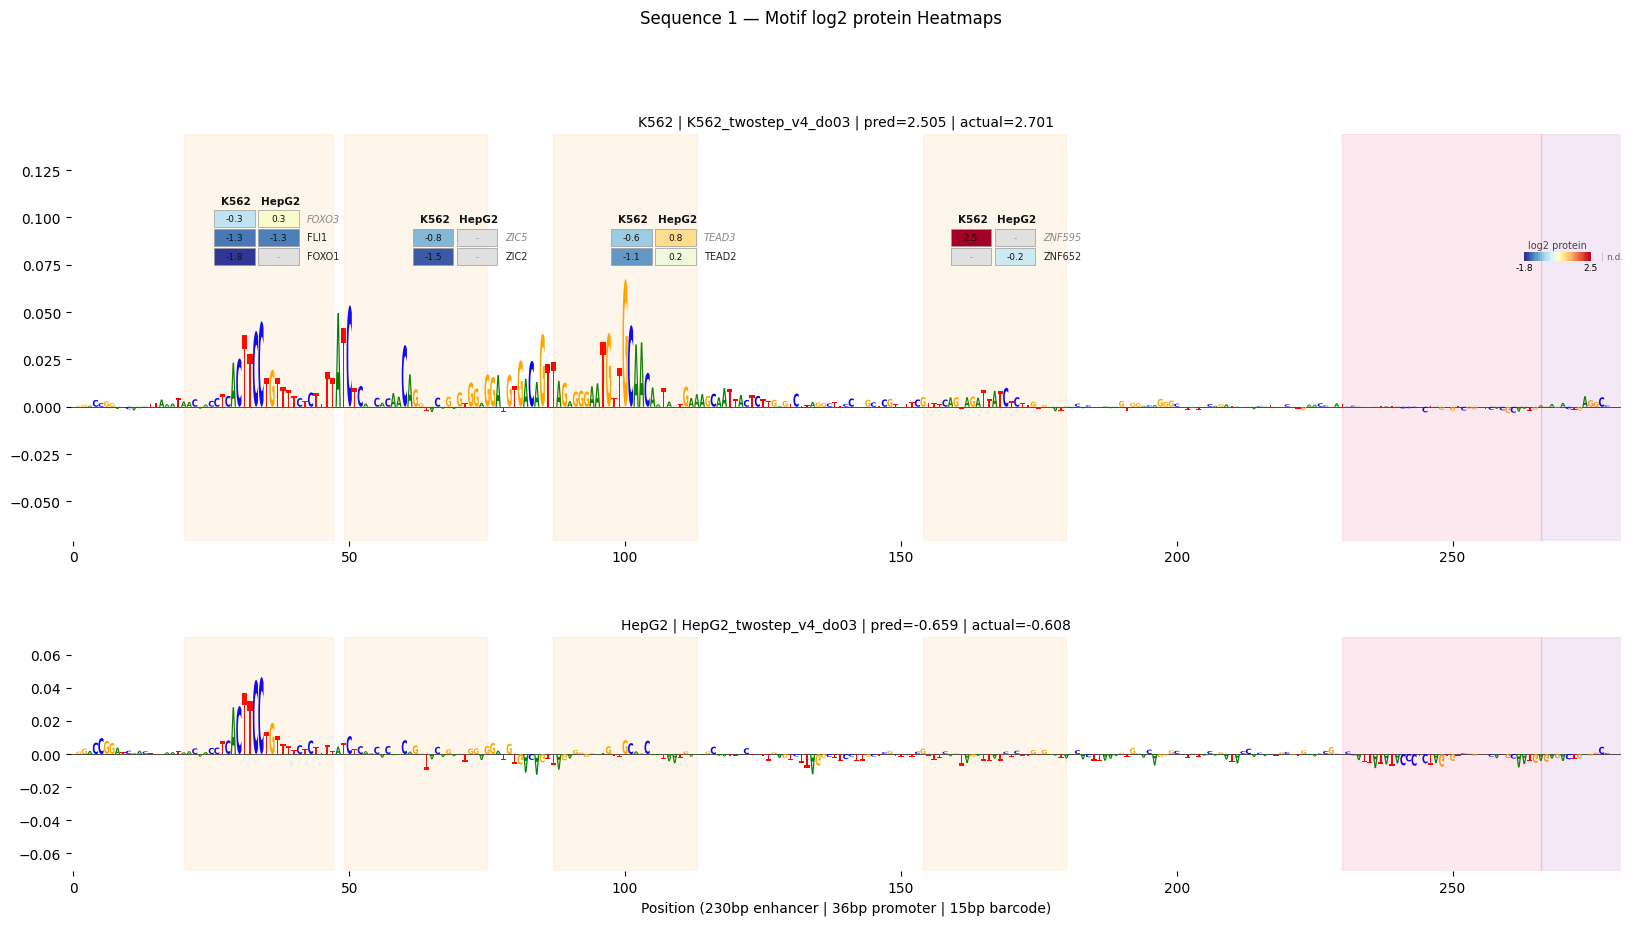

In [18]:
# Auto-clear bytecode + reload
for pyc in pathlib.Path('..', '__pycache__').glob('eigen_steering.cpython-*.pyc'):
    pyc.unlink(missing_ok=True)
importlib.reload(eigen_steering)
from eigen_steering import EigenMap

# CCLE mass-spec proteomics cross-reference
em.load_proteome()

# annotation_style='heatmap' or 'bars'
em.plot_proteome_match(seq_idx=seq_idx, top_k=1, max_paralogs=1, annotation_style='heatmap')